In [1]:
# Cell 1: Environment Setup

include("helpers/initialization_helpers.jl")
include("helpers/initialization_dictionaries.jl")
using .InitializationHelpers
using .InitializationDictionaries
using OMJulia
using Plots, DataFrames, CSV

# --- Configuration ---

# 1. Directory containing the original dynamic package
MODEL_DIR = abspath("MyNordic")
MODELS_PKG_PATH = joinpath(MODEL_DIR, "package.mo")

# 2. Directory containing the auxiliary package generated by BuildAux_package.ipynb
AUX_DIR = abspath("MyNordic_auxiliary")
AUX_PACKAGE_FILE = joinpath(AUX_DIR, "package.mo")

# 3. Root dynamic model to initialize
MODEL = "MyNordic.TestCase"

# 4. Derived package/model names
SOURCE_PACKAGE = split(MODEL, ".")[1]
ROOT_MODEL_NAME = split(MODEL, ".")[end]

AUX_PACKAGE = SOURCE_PACKAGE * "_auxiliary"
AUX_ROOT_MODEL = AUX_PACKAGE * "." * ROOT_MODEL_NAME * "_auxiliary"

INITIALIZED_PACKAGE = SOURCE_PACKAGE * "_initialized"
INITIALIZED_DIR = joinpath(dirname(MODEL_DIR), INITIALIZED_PACKAGE)
INITIALIZED_ROOT_MODEL = INITIALIZED_PACKAGE * "." * ROOT_MODEL_NAME * "_initialized"
INITIALIZED_PACKAGE_FILE = joinpath(INITIALIZED_DIR, "package.mo")
INITIALIZED_ORDER_FILE = joinpath(INITIALIZED_DIR, "package.order")

# 5. Output directories for OpenModelica build artifacts
RUN_OUTPUT_DIR = abspath(INITIALIZED_PACKAGE * "_outputs")
mkpath(RUN_OUTPUT_DIR)

# 6. Library paths
DYNAWO_PKG_PATH = "/home/clarafercas/Model_library/dynawo/dynawo/sources/Models/Modelica/Dynawo/package.mo"
MODELICA_PKG_PATH = "/home/clarafercas/dynawo/OpenModelica/lib/omlibrary/Modelica/package.mo"

# 7. Placeholder plot variable for the final initialized simulation
PLOT_VARIABLE = "g20.terminal.V.re"


"g20.terminal.V.re"

In [2]:
# Cell 2: Package helper functions

function inherited_classes(omc, model::String)
    raw = strip(String(om_send(omc, "getInheritedClasses($model)", parsed = false)))
    raw = replace(raw, "{" => "", "}" => "", ";" => "", "\"" => "")
    isempty(strip(raw)) && return String[]

    parents = String[]
    for parent in split(raw, ",")
        parent = strip(parent)
        isempty(parent) && continue
        startswith(parent, "Modelica.Icons") && continue
        startswith(parent, "Dynawo.Icons") && continue
        push!(parents, parent)
    end

    return parents
end

function get_inheritance_chain(omc, root::String)
    chain = String[]
    seen = Set{String}()

    function visit(model::String)
        model in seen && return
        push!(seen, model)

        for parent in inherited_classes(omc, model)
            visit(parent)
        end

        push!(chain, model)
    end

    visit(root)
    return chain
end

function rewrite_initialized_extends(txt::String, initialized_name_map::Dict{String, String})
    rewritten = txt
    for (original_parent, initialized_parent) in initialized_name_map
        rewritten = replace(rewritten, "extends " * original_parent * ";" => "extends " * initialized_parent * ";")
        rewritten = replace(rewritten, "extends " * original_parent * "(" => "extends " * initialized_parent * "(")
    end
    return rewritten
end


rewrite_initialized_extends (generic function with 1 method)

In [3]:
# Cell 3: OpenModelica Setup + Package Loading

# 1. Load the original dynamic package
SourceOMC = OMJulia.OMCSession()
om_send(SourceOMC, "loadFile(\"$MODELICA_PKG_PATH\")")
om_send(SourceOMC, "loadModel(Complex)")
om_send(SourceOMC, "loadModel(ModelicaServices)")
om_send(SourceOMC, "loadFile(\"$DYNAWO_PKG_PATH\")")
om_send(SourceOMC, "loadFile(\"$MODELS_PKG_PATH\")")
om_send(SourceOMC, "clearMessages()")
println("Checking the dynamic root model...")
chk_source = om_send(SourceOMC, "checkModel($MODEL)", parsed=false)
println(chk_source)

# 2. Load the auxiliary package
AuxOMC = OMJulia.OMCSession()
om_send(AuxOMC, "loadFile(\"$MODELICA_PKG_PATH\")")
om_send(AuxOMC, "loadModel(Complex)")
om_send(AuxOMC, "loadModel(ModelicaServices)")
om_send(AuxOMC, "loadFile(\"$DYNAWO_PKG_PATH\")")
om_send(AuxOMC, "loadFile(\"$AUX_PACKAGE_FILE\")")
om_send(AuxOMC, "clearMessages()")
println("Checking the auxiliary root model...")
chk_aux = om_send(AuxOMC, "checkModel($AUX_ROOT_MODEL)", parsed=false)
println(chk_aux)


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.V7j1Vwr3K9"


OMC -> loadFile("/home/clarafercas/dynawo/OpenModelica/lib/omlibrary/Modelica/package.mo")
OMC -> loadModel(Complex)
OMC -> loadModel(ModelicaServices)
OMC -> loadFile("/home/clarafercas/Model_library/dynawo/dynawo/sources/Models/Modelica/Dynawo/package.mo")
OMC -> loadFile("/home/clarafercas/dynawo-notebooks/OpenModelica_only_users/Initialization/MyNordic/package.mo")
OMC -> clearMessages()
Checking the dynamic root model...
OMC -> checkModel(MyNordic.TestCase)
"Check of MyNordic.TestCase completed successfully.
Class MyNordic.TestCase has 6622 equation(s) and 6622 variable(s).
2846 of these are trivial equation(s)."

OMC -> loadFile("/home/clarafercas/dynawo/OpenModelica/lib/omlibrary/Modelica/package.mo")


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.QxHXgDnV0o"


OMC -> loadModel(Complex)
OMC -> loadModel(ModelicaServices)
OMC -> loadFile("/home/clarafercas/Model_library/dynawo/dynawo/sources/Models/Modelica/Dynawo/package.mo")
OMC -> loadFile("/home/clarafercas/dynawo-notebooks/OpenModelica_only_users/Initialization/MyNordic_auxiliary/package.mo")
OMC -> clearMessages()
Checking the auxiliary root model...
OMC -> checkModel(MyNordic_auxiliary.TestCase_auxiliary)
"Check of MyNordic_auxiliary.TestCase_auxiliary completed successfully.
Class MyNordic_auxiliary.TestCase_auxiliary has 5819 equation(s) and 5819 variable(s).
1550 of these are trivial equation(s)."



In [4]:
# Cell 4: Inheritance Chain + Package Name Mapping

chain = get_inheritance_chain(SourceOMC, MODEL)
println("Inheritance chain:")
println(chain)

AUX_NAME_MAP = Dict(model => AUX_PACKAGE * "." * split(model, ".")[end] * "_auxiliary" for model in chain)
INITIALIZED_NAME_MAP = Dict(model => INITIALIZED_PACKAGE * "." * split(model, ".")[end] * "_initialized" for model in chain)

println("\nInitialized class map:")
for model in chain
    println("  ", model, " -> ", INITIALIZED_NAME_MAP[model])
end

INIT_MODEL_BY_COMPONENT = Dict{String, String}(
    "g01" => "GeneratorSynchronousExt3W_INIT",
    "g02" => "GeneratorSynchronousExt3W_INIT",
    "g03" => "GeneratorSynchronousExt3W_INIT",
    "g04" => "GeneratorSynchronousExt3W_INIT",
    "g05" => "GeneratorSynchronousExt3W_INIT",
    "g06" => "GeneratorSynchronousExt4W_INIT",
    "g07" => "GeneratorSynchronousExt4W_INIT",
    "g08" => "GeneratorSynchronousExt3W_INIT",
    "g09" => "GeneratorSynchronousExt3W_INIT",
    "g10" => "GeneratorSynchronousExt3W_INIT",
    "g11" => "GeneratorSynchronousExt3W_INIT",
    "g12" => "GeneratorSynchronousExt3W_INIT",
    "g13" => "GeneratorSynchronousExt3W_INIT",
    "g14" => "GeneratorSynchronousExt4W_INIT",
    "g15" => "GeneratorSynchronousExt4W_INIT",
    "g16" => "GeneratorSynchronousExt4W_INIT",
    "g17" => "GeneratorSynchronousExt4W_INIT",
    "g18" => "GeneratorSynchronousExt4W_INIT",
    "g19" => "GeneratorSynchronousExt3W_INIT",
    "g20" => "GeneratorSynchronousExt3W_INIT",
)


OMC -> getInheritedClasses(MyNordic.TestCase)
OMC -> getInheritedClasses(MyNordic.FullDynamicModel)
OMC -> getInheritedClasses(MyNordic.NetworkWithAlphaBetaLoads)
OMC -> getInheritedClasses(MyNordic.Network)
Inheritance chain:
["MyNordic.Network", "MyNordic.NetworkWithAlphaBetaLoads", "MyNordic.FullDynamicModel", "MyNordic.TestCase"]

Initialized class map:
  MyNordic.Network -> MyNordic_initialized.Network_initialized
  MyNordic.NetworkWithAlphaBetaLoads -> MyNordic_initialized.NetworkWithAlphaBetaLoads_initialized
  MyNordic.FullDynamicModel -> MyNordic_initialized.FullDynamicModel_initialized
  MyNordic.TestCase -> MyNordic_initialized.TestCase_initialized


Dict{String, String} with 20 entries:
  "g02" => "GeneratorSynchronousExt3W_INIT"
  "g15" => "GeneratorSynchronousExt4W_INIT"
  "g09" => "GeneratorSynchronousExt3W_INIT"
  "g19" => "GeneratorSynchronousExt3W_INIT"
  "g13" => "GeneratorSynchronousExt3W_INIT"
  "g14" => "GeneratorSynchronousExt4W_INIT"
  "g12" => "GeneratorSynchronousExt3W_INIT"
  "g20" => "GeneratorSynchronousExt3W_INIT"
  "g11" => "GeneratorSynchronousExt3W_INIT"
  "g03" => "GeneratorSynchronousExt3W_INIT"
  "g05" => "GeneratorSynchronousExt3W_INIT"
  "g07" => "GeneratorSynchronousExt4W_INIT"
  "g16" => "GeneratorSynchronousExt4W_INIT"
  "g17" => "GeneratorSynchronousExt4W_INIT"
  "g06" => "GeneratorSynchronousExt4W_INIT"
  "g08" => "GeneratorSynchronousExt3W_INIT"
  "g18" => "GeneratorSynchronousExt4W_INIT"
  "g10" => "GeneratorSynchronousExt3W_INIT"
  "g04" => "GeneratorSynchronousExt3W_INIT"
  "g01" => "GeneratorSynchronousExt3W_INIT"

In [5]:
# Cell 5: Simulate Auxiliary Package + Extract Initialization Values

# Build and simulate the auxiliary root model.
ModelicaSystem(AuxOMC, AUX_PACKAGE_FILE, AUX_ROOT_MODEL, [MODELICA_PKG_PATH, DYNAWO_PKG_PATH])
simulate(AuxOMC, resultfile = AUX_PACKAGE * "_res.mat")

# Extract initialization values per original class in the inheritance chain.
components_by_model = Dict{String, Dict{String, Dict{String, Any}}}()
initializable_by_model = Dict{String, Dict{String, Dict{String, Any}}}()
init_values_by_model = Dict{String, Dict{String, Dict{String, Float64}}}()

for model in chain
    components = get_all_components(SourceOMC, model)
    initializable_components = get_initializable_components(components, INIT_PARAMS, INIT_MODEL_BY_COMPONENT)
    init_values_by_component = extract_all_initialization_values(AuxOMC, initializable_components, INIT_PARAMS, INIT_MODEL_BY_COMPONENT)

    components_by_model[model] = components
    initializable_by_model[model] = initializable_components
    init_values_by_model[model] = init_values_by_component

    println(model, ": ", length(initializable_components), " initializable component(s)")
end


MyNordic.Network: 0 initializable component(s)
MyNordic.NetworkWithAlphaBetaLoads: 22 initializable component(s)
MyNordic.FullDynamicModel: 20 initializable component(s)
MyNordic.TestCase: 0 initializable component(s)


In [6]:
# Cell 6: Build and save the initialized package
om_send(SourceOMC, "deleteClass($INITIALIZED_PACKAGE)")
om_send(SourceOMC, "clearMessages()")
om_send(SourceOMC, "loadString(\"within ; package $INITIALIZED_PACKAGE end $INITIALIZED_PACKAGE;\")")

for model in chain
    initialized_model = INITIALIZED_NAME_MAP[model]
    initialized_name = split(initialized_model, ".")[end]

    println("Copying and initializing ", model, " -> ", initialized_model)
    om_send(SourceOMC, "copyClass($model, \"$initialized_name\", $INITIALIZED_PACKAGE)")

    apply_initialization_modifiers!(
        SourceOMC,
        initialized_model,
        initializable_by_model[model],
        INIT_PARAMS,
        init_values_by_model[model],
        INIT_MODEL_BY_COMPONENT,
    )
end

mkpath(INITIALIZED_DIR)

open(INITIALIZED_PACKAGE_FILE, "w") do io
    print(io, "within ;\npackage $INITIALIZED_PACKAGE\nend $INITIALIZED_PACKAGE;\n")
end

open(INITIALIZED_ORDER_FILE, "w") do io
    for model in chain
        println(io, split(INITIALIZED_NAME_MAP[model], ".")[end])
    end
end

for model in chain
    initialized_model = INITIALIZED_NAME_MAP[model]
    initialized_name = split(initialized_model, ".")[end]
    initialized_file = joinpath(INITIALIZED_DIR, initialized_name * ".mo")

    txt = String(om_send(SourceOMC, "listFile($initialized_model)"))
    txt = rewrite_initialized_extends(txt, INITIALIZED_NAME_MAP)

    open(initialized_file, "w") do io
        print(io, txt)
        endswith(txt, "\n") || print(io, "\n")
    end
end

InitializedOMC = OMJulia.OMCSession()
om_send(InitializedOMC, "loadFile(\"$MODELICA_PKG_PATH\")")
om_send(InitializedOMC, "loadModel(Complex)")
om_send(InitializedOMC, "loadModel(ModelicaServices)")
om_send(InitializedOMC, "loadFile(\"$DYNAWO_PKG_PATH\")")
om_send(InitializedOMC, "loadFile(\"$INITIALIZED_PACKAGE_FILE\")")
om_send(InitializedOMC, "clearMessages()")
println("Checking the initialized root model...")
chk_initialized = om_send(InitializedOMC, "checkModel($INITIALIZED_ROOT_MODEL)", parsed=false)
println(chk_initialized)


OMC -> deleteClass(MyNordic_initialized)
OMC -> clearMessages()
OMC -> loadString("within ; package MyNordic_initialized end MyNordic_initialized;")
Copying and initializing MyNordic.Network -> MyNordic_initialized.Network_initialized
OMC -> copyClass(MyNordic.Network, "Network_initialized", MyNordic_initialized)
Copying and initializing MyNordic.NetworkWithAlphaBetaLoads -> MyNordic_initialized.NetworkWithAlphaBetaLoads_initialized
OMC -> copyClass(MyNordic.NetworkWithAlphaBetaLoads, "NetworkWithAlphaBetaLoads_initialized", MyNordic_initialized)
OMC -> updateComponent(load_04, Dynawo.Electrical.Loads.LoadAlphaBeta, MyNordic_initialized.NetworkWithAlphaBetaLoads_initialized, modification = $Code((u0Pu = Complex(1.0, 0.0), i0Pu = Complex(8.4, -2.52), alpha = Alpha, s0Pu = Complex(8.4, 2.52), beta = Beta)))
OMC -> updateComponent(load_46, Dynawo.Electrical.Loads.LoadAlphaBeta, MyNordic_initialized.NetworkWithAlphaBetaLoads_initialized, modification = $Code((u0Pu = Complex(1.0, 0.0), i0Pu

[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.CDBFBfkaDP"


OMC -> loadModel(Complex)
OMC -> loadModel(ModelicaServices)
OMC -> loadFile("/home/clarafercas/Model_library/dynawo/dynawo/sources/Models/Modelica/Dynawo/package.mo")
OMC -> loadFile("/home/clarafercas/dynawo-notebooks/OpenModelica_only_users/Initialization/MyNordic_initialized/package.mo")
OMC -> clearMessages()
Checking the initialized root model...
OMC -> checkModel(MyNordic_initialized.TestCase_initialized)
"Check of MyNordic_initialized.TestCase_initialized completed successfully.
Class MyNordic_initialized.TestCase_initialized has 6622 equation(s) and 6622 variable(s).
2846 of these are trivial equation(s)."



In [7]:
# Cell 7: Final simulation of the initialized package

InitializedRunOMC = OMJulia.OMCSession()
om_send(InitializedRunOMC, "loadFile(\"$MODELICA_PKG_PATH\")")
om_send(InitializedRunOMC, "loadModel(Complex)")
om_send(InitializedRunOMC, "loadModel(ModelicaServices)")
om_send(InitializedRunOMC, "loadFile(\"$DYNAWO_PKG_PATH\")")
om_send(InitializedRunOMC, "clearMessages()")

ModelicaSystem(
    InitializedRunOMC,
    INITIALIZED_PACKAGE_FILE,
    INITIALIZED_ROOT_MODEL,
    [MODELICA_PKG_PATH, DYNAWO_PKG_PATH],
    customBuildDirectory = RUN_OUTPUT_DIR,
)

initialized_resultfile_name = INITIALIZED_PACKAGE * "_res.csv"
simulate(InitializedRunOMC, resultfile = initialized_resultfile_name, simflags = "-outputFormat=csv")
initialized_resultfile = joinpath(getWorkDirectory(InitializedRunOMC), initialized_resultfile_name)
println("Initialized simulation result: ", initialized_resultfile)


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.WYjYXM4F5o"


OMC -> loadFile("/home/clarafercas/dynawo/OpenModelica/lib/omlibrary/Modelica/package.mo")
OMC -> loadModel(Complex)
OMC -> loadModel(ModelicaServices)
OMC -> loadFile("/home/clarafercas/Model_library/dynawo/dynawo/sources/Models/Modelica/Dynawo/package.mo")
OMC -> clearMessages()
Initialized simulation result: /tmp/jl_MOJKHn/MyNordic_initialized_res.csv


WebIO._IJuliaInit()

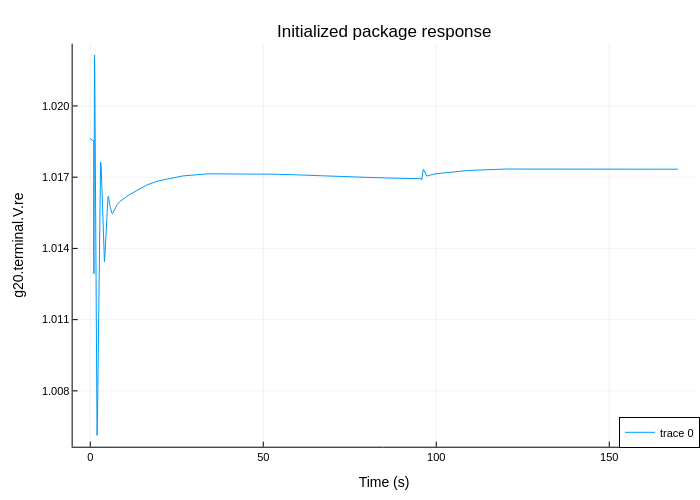

In [8]:
# Cell 8: Plot the initialized package response

initialized_df = DataFrame(CSV.File(initialized_resultfile; select = ["time", PLOT_VARIABLE]))

plotlyjs()
p = plot(initialized_df[!, "time"], initialized_df[!, PLOT_VARIABLE], label = [PLOT_VARIABLE])
plot!(p, legend = :bottomright, titlefontsize = 12, labelfontsize = 10)
title!(p, "Initialized package response")
xlabel!(p, "Time (s)")
ylabel!(p, PLOT_VARIABLE)


In [9]:
# Cell 9: OMC diagnostics for failed initialized simulation

# Run this cell after the final simulation cell fails.

function _print_omc_errors(omc, label::String)
    raw = String(sendExpression(omc, "getErrorString()", parsed=false))
    txt = strip(replace(raw, "\"" => ""))
    println("\n[$label] getErrorString()")
    if isempty(txt)
        println("<no messages>")
    else
        println(raw)
    end
end

function _run_omc_diagnostic(omc, label::String, expr::String)
    sendExpression(omc, "clearMessages()")
    println("\n=== $label ===")
    println("OMC -> ", expr)
    try
        result = sendExpression(omc, expr, parsed=false)
        println(result)
    catch err
        println("Julia/OMJulia error while running: ", expr)
        showerror(stdout, err)
        println()
    end
    _print_omc_errors(omc, label)
end

println("=== Initialized package OMC diagnostics start ===")

if isdefined(Main, :InitializedRunOMC)
    _print_omc_errors(InitializedRunOMC, "after failed final simulation cell")
end

DiagnosticOMC = OMJulia.OMCSession()
om_send(DiagnosticOMC, "loadFile(\"$MODELICA_PKG_PATH\")")
om_send(DiagnosticOMC, "loadModel(Complex)")
om_send(DiagnosticOMC, "loadModel(ModelicaServices)")
om_send(DiagnosticOMC, "loadFile(\"$DYNAWO_PKG_PATH\")")
om_send(DiagnosticOMC, "loadFile(\"$INITIALIZED_PACKAGE_FILE\")")
om_send(DiagnosticOMC, "cd(\"$RUN_OUTPUT_DIR\")")
_print_omc_errors(DiagnosticOMC, "after loading initialized package")

_run_omc_diagnostic(DiagnosticOMC, "checkModel($INITIALIZED_ROOT_MODEL)", "checkModel($INITIALIZED_ROOT_MODEL)")

if isdefined(Main, :chain) && isdefined(Main, :INITIALIZED_NAME_MAP)
    for model in chain
        initialized_model = INITIALIZED_NAME_MAP[model]
        _run_omc_diagnostic(DiagnosticOMC, "checkModel($initialized_model)", "checkModel($initialized_model)")
    end
end

_run_omc_diagnostic(DiagnosticOMC, "instantiateModel($INITIALIZED_ROOT_MODEL)", "instantiateModel($INITIALIZED_ROOT_MODEL)")
_run_omc_diagnostic(DiagnosticOMC, "buildModel($INITIALIZED_ROOT_MODEL)", "buildModel($INITIALIZED_ROOT_MODEL)")

println("=== Initialized package OMC diagnostics end ===")


=== Initialized package OMC diagnostics start ===

[after failed final simulation cell] getErrorString()
"Notification: Modelica requested package Complex of version 3.2.3. Complex 4.1.0 is used instead which states that it is fully compatible without conversion script needed.
Notification: Modelica requested package ModelicaServices of version 3.2.3. ModelicaServices 4.1.0 is used instead which states that it is fully compatible without conversion script needed.
[/home/clarafercas/Model_library/dynawo/dynawo/sources/Models/Modelica/Dynawo/Electrical/Controls/Basics/SwitchOff/SwitchOffLogic.mo:20:3-20:98:writable] Warning: Connector switchOffSignal1 is not balanced: The number of potential variables (1) is not equal to the number of flow variables (0).
[/home/clarafercas/Model_library/dynawo/dynawo/sources/Models/Modelica/Dynawo/Electrical/Controls/Basics/SwitchOff/SwitchOffLogic.mo:21:3-21:125:writable] Warning: Connector switchOffSignal2 is not balanced: The number of potential varia

[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.hd6IVMRisl"


OMC -> loadFile("/home/clarafercas/dynawo/OpenModelica/lib/omlibrary/Modelica/package.mo")
OMC -> loadModel(Complex)
OMC -> loadModel(ModelicaServices)
OMC -> loadFile("/home/clarafercas/Model_library/dynawo/dynawo/sources/Models/Modelica/Dynawo/package.mo")
OMC -> loadFile("/home/clarafercas/dynawo-notebooks/OpenModelica_only_users/Initialization/MyNordic_initialized/package.mo")

[after loading initialized package] getErrorString()
"Notification: Automatically loaded package Complex 4.1.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.1.0 due to uses annotation from Modelica.
[/home/clarafercas/Model_library/dynawo/dynawo/sources/Models/Modelica/Dynawo/Examples/BESS/WECC/package.order:0:0-0:0:readonly] Warning: The package.order file does not list all .mo files and directories (containing package.mo) present in its directory.
Missing names are:
	MyBESS_static
	MyBESS
"


=== checkModel(MyNordic_initialized.TestCase_initialized) ===

Excessive output truncated after 565597 bytes.